**[Sentimento imdb](https://www.kaggle.com/luisfredgs/imdb-ptbr):
O dataset imdb é um dos mais famosos benchmarks para modelos de classificação de textos que existe. Dificilmente não será citado em papers que proponham trabalhos envolvendo este tipo de tarefa.**

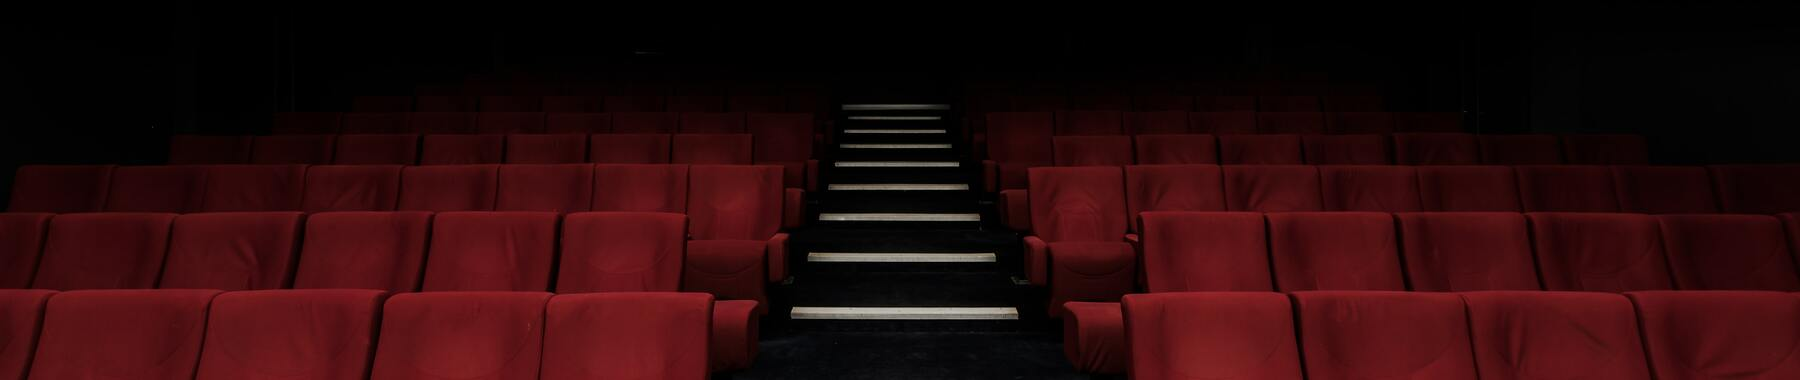

In [1]:
!pip3 install unidecode

     |████████████████████████████████| 235 kB 7.7 MB/s 


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings
import random
import pickle
import unidecode
import string
import nltk
import io
import os
import time
import zipfile
import requests
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score, precision_score, recall_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix, hstack
from sklearn.metrics import confusion_matrix
from matplotlib.ticker import FuncFormatter
from nltk import tokenize
from nltk.corpus import stopwords
from wordcloud import WordCloud
from string import punctuation
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers

%matplotlib inline
np.random.seed(1)
warnings.filterwarnings('ignore', 'Maximum number of iteration reached before convergence.*') #Sem isso aqui ele fica falando pra aumentar o max_iter
warnings.filterwarnings('ignore', 'Liblinear failed to converge, increase the number of iterations.*') #Sem isso aqui ele fica falando pra aumentar o max_iter
warnings.filterwarnings('ignore', 'Warm-start fitting without increasing n_estimators does not fit new trees.*') #Sem isso aqui ele fica falando pra aumentar o max_iter


**Processo de download automático dos dados**

In [3]:
!gdown --id '1gYQ8xaPu4IhIqtQGKhKHW4Q6AJkjeLsv'

Downloading...
From: https://drive.google.com/uc?id=1gYQ8xaPu4IhIqtQGKhKHW4Q6AJkjeLsv
To: /content/sentimento.csv
100% 127M/127M [00:00<00:00, 177MB/s]


**Tratamento de dados**

In [4]:
df_sentimento = pd.read_csv('sentimento.csv')

In [5]:
df_sentimento = df_sentimento.drop(columns=['id','text_en'])

In [6]:
df_sentimento

,text_pt,sentiment
0,"Mais uma vez, o Sr. Costner arrumou um filme p...",neg
1,Este é um exemplo do motivo pelo qual a maiori...,neg
2,"Primeiro de tudo eu odeio esses raps imbecis, ...",neg
3,Nem mesmo os Beatles puderam escrever músicas ...,neg
4,Filmes de fotos de latão não é uma palavra apr...,neg
...,...,...
49454,"Como a média de votos era muito baixa, e o fat...",pos
49455,O enredo teve algumas reviravoltas infelizes e...,pos
49456,Estou espantado com a forma como este filme e ...,pos
49457,A Christmas Together realmente veio antes do m...,pos


In [7]:
df_sentimento.isna().sum()

text_pt      0
sentiment    0
dtype: int64

In [ ]:
df_sentimento.dtypes

text_pt      object
sentiment    object
dtype: object

In [7]:
df_sentimento['sentiment'].unique()

array(['neg', 'pos'], dtype=object)

In [8]:
df_sentimento = pd.get_dummies(df_sentimento,columns=['sentiment'], drop_first=False)

In [ ]:
df_sentimento

,text_pt,sentiment_neg,sentiment_pos
0,"Mais uma vez, o Sr. Costner arrumou um filme p...",1,0
1,Este é um exemplo do motivo pelo qual a maiori...,1,0
2,"Primeiro de tudo eu odeio esses raps imbecis, ...",1,0
3,Nem mesmo os Beatles puderam escrever músicas ...,1,0
4,Filmes de fotos de latão não é uma palavra apr...,1,0
...,...,...,...
49454,"Como a média de votos era muito baixa, e o fat...",0,1
49455,O enredo teve algumas reviravoltas infelizes e...,0,1
49456,Estou espantado com a forma como este filme e ...,0,1
49457,A Christmas Together realmente veio antes do m...,0,1


In [ ]:
df_sentimento.dtypes

text_pt          object
sentiment_neg     uint8
sentiment_pos     uint8
dtype: object

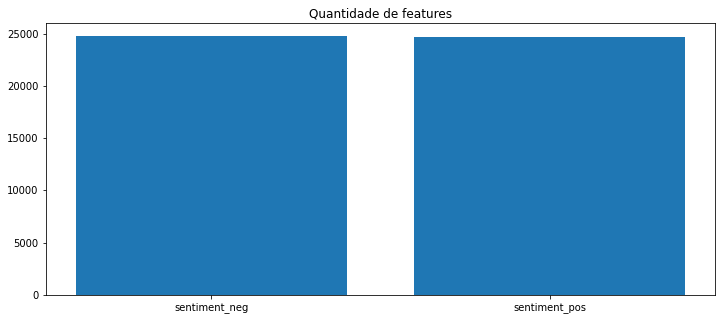

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(df_sentimento.iloc[:,1:].columns.array, df_sentimento.iloc[:,1:].sum().array)
plt.title('Quantidade de features')
plt.show()

In [ ]:
def nuvemPalavras(df,titulo,coluna):
  todas_palavras = ' '.join([texto for texto in df[coluna]])
  nuvem_palvras = WordCloud(width= 800,height= 500,max_font_size = 110,collocations = False,background_color ='white').generate(todas_palavras)
  plt.figure(figsize=(10,7))
  plt.imshow(nuvem_palvras, interpolation='bilinear')
  plt.title(titulo,fontsize=16)
  plt.axis("off")

  plt.show()

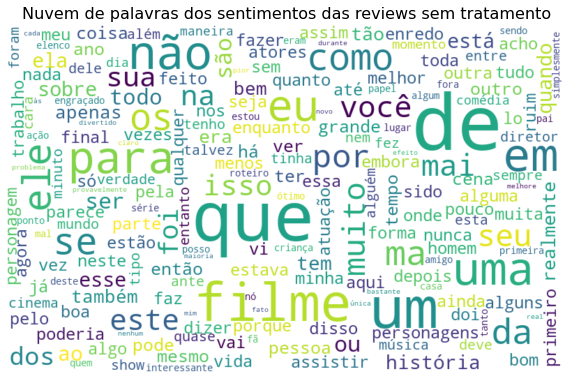

In [ ]:
nuvemPalavras(df_sentimento,'Nuvem de palavras dos sentimentos das reviews sem tratamento','text_pt')

In [ ]:
def graficoPareto(df,coluna,n):
  todas_palavras = ' '.join([texto for texto in df[coluna]])
  token_frase = tokenize.WhitespaceTokenizer().tokenize(todas_palavras)
  frequencia = nltk.FreqDist(token_frase)
  df_frequencia = pd.DataFrame({"Palavra": list(frequencia.keys()),"Frequência": list(frequencia.values())})
  df_frequencia = df_frequencia.nlargest(columns = "Frequência", n = n)
  plt.figure(figsize=(12,8))
  ax = sns.barplot(data = df_frequencia, x = "Palavra", y = "Frequência", color = 'gray')
  ax.set(ylabel = "Contagem")
  plt.title('Recorrência das palavras')
  plt.rcParams.update({'font.size': 12})
  plt.show()

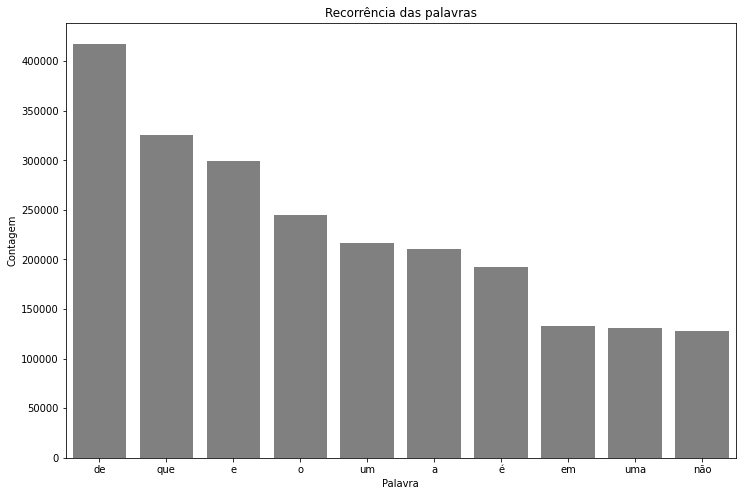

In [ ]:
graficoPareto(df_sentimento,'text_pt',10)

In [ ]:
def processarTexto(df):
  nltk.download('stopwords')
  nltk.download('rslp')
  translator = str.maketrans('', '', string.punctuation)
  stemmer = nltk.RSLPStemmer()
  pontuacao_stopwords = stopwords.words('portuguese')
  texto_lista = list()
  for texto in df['text_pt']:
      nova_frase = list()
      texto = unidecode.unidecode(texto).lower().translate(translator)
      palavras_texto = tokenize.WhitespaceTokenizer().tokenize(texto)
      for palavra in palavras_texto:
          if palavra not in pontuacao_stopwords:
              nova_frase.append(stemmer.stem(palavra))
      texto_lista.append(' '.join(nova_frase))
        
  df[f'text_pt_processed'] = texto_lista

In [ ]:
processarTexto(df_sentimento) 

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Unzipping stemmers/rslp.zip.


In [ ]:
df_sentimento

,text_pt,sentiment_neg,sentiment_pos,text_pt_processed
0,"Mais uma vez, o Sr. Costner arrumou um filme p...",1,0,vez sr costn arrum film temp necessari alem te...
1,Este é um exemplo do motivo pelo qual a maiori...,1,0,exempl motiv maior film aca sao mesm gener cha...
2,"Primeiro de tudo eu odeio esses raps imbecis, ...",1,0,prim tud odei rap imbecil nao pod agir arm pre...
3,Nem mesmo os Beatles puderam escrever músicas ...,1,0,beatl pud escrev music tod gost emb walt hill ...
4,Filmes de fotos de latão não é uma palavra apr...,1,0,film fot lata nao palavr apropri verdad sao ta...
...,...,...,...,...
49454,"Como a média de votos era muito baixa, e o fat...",0,1,med vot baix fat funcionari loc ach tud bem na...
49455,O enredo teve algumas reviravoltas infelizes e...,0,1,enred algum reviravolt infeliz inacredita enta...
49456,Estou espantado com a forma como este filme e ...,0,1,espant form film maior outr med 5 estrel men h...
49457,A Christmas Together realmente veio antes do m...,0,1,christm togeth real vei ant temp cri john denv...


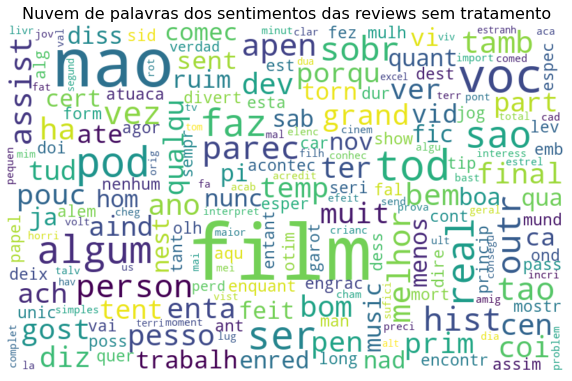

In [ ]:
nuvemPalavras(df_sentimento,'Nuvem de palavras dos sentimentos das reviews sem tratamento','text_pt_processed')

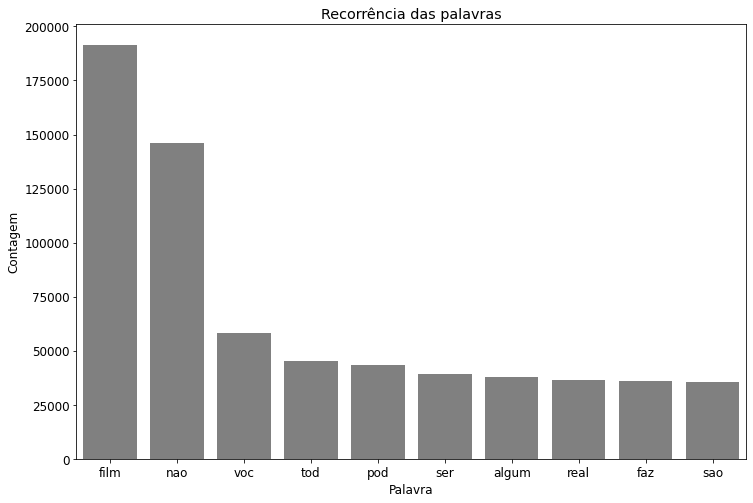

In [ ]:
graficoPareto(df_sentimento,'text_pt_processed',10)

In [ ]:
def separarDados(x,y):
  train_ratio = 0.60
  validation_ratio = 0.20
  test_ratio = 0.20

  x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=1 - train_ratio)

  x_validacao, x_teste, y_validacao, y_teste = train_test_split(x_teste, y_teste, test_size=test_ratio/(test_ratio + validation_ratio))

  return x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste

In [ ]:
def prepararConjuntosCountVectorizer(df,features):
  vetorizar = CountVectorizer(lowercase=False, max_features=features)

  x = vetorizar.fit_transform(df['text_pt_processed'])
  y = df['sentiment_neg']

  return separarDados(x,y)

In [ ]:
def prepararConjuntosTfidfVectorizer(df,features):
  vetorizar = TfidfVectorizer(lowercase=False, max_features=features)

  x = vetorizar.fit_transform(df['text_pt_processed'])
  y = df['sentiment_neg']

  return separarDados(x,y)

In [ ]:
for features in range(926,927,25):
  x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararConjuntosCountVectorizer(df_sentimento,features)
  modelo = LogisticRegression(solver="lbfgs", max_iter = 150)
  modelo.fit(x_treino, y_treino)

  filename = 'modelo1.sav'
  pickle.dump(modelo, open(filename, 'wb'))

  y_pred = modelo.predict(x_validacao)
  
  print(f'Acurácia do modelo na validação é {round(accuracy_score(y_validacao, y_pred)*100,2)}% com {features} features.')
  print(f'Precisão do modelo na validação é {round(precision_score(y_validacao, y_pred)*100,2)}% com {features} features.')
  print(f'Recall do modelo na validação é {round(recall_score(y_validacao, y_pred)*100,2)}% com {features} features.')
  print()

Acurácia do modelo na validação é 85.35% com 926 features.
Precisão do modelo na validação é 85.3% com 926 features.
Recall do modelo na validação é 85.0% com 926 features.



In [ ]:
for features in range(926,927,25):
  x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararConjuntosTfidfVectorizer(df_sentimento,features)
  modelo = LogisticRegression(solver="lbfgs", max_iter = 150)
  modelo.fit(x_treino, y_treino)

  filename = 'modelo2.sav'
  pickle.dump(modelo, open(filename, 'wb'))

  y_pred = modelo.predict(x_validacao)

  print(f'Acurácia do modelo na validação é {round(accuracy_score(y_validacao, y_pred)*100,2)}% com {features} features.')
  print(f'Precisão do modelo na validação é {round(precision_score(y_validacao, y_pred)*100,2)}% com {features} features.')
  print(f'Recall do modelo na validação é {round(recall_score(y_validacao, y_pred)*100,2)}% com {features} features.')
  print()

Acurácia do modelo na validação é 85.93% com 926 features.
Precisão do modelo na validação é 86.54% com 926 features.
Recall do modelo na validação é 85.36% com 926 features.



In [ ]:
def plotarGrafico(historico,valor1,valor2,valor3,valor4):
    plt.figure(figsize=(10, 8))
    plt.plot(historico.history[valor1])
    plt.plot(historico.history[valor2])
    plt.title(valor3)
    plt.xlabel('Épocas')
    plt.ylabel(valor4)
    plt.legend(['Treino', 'Validação'])
    plt.rcParams.update({'font.size': 12})
    plt.show()

In [ ]:
max_length = 50
vocab_size = 6000

tokenizer = Tokenizer(oov_token = "<OOV>", num_words=vocab_size)
tokenizer.fit_on_texts(df_sentimento['text_pt_processed'])

sequences = tokenizer.texts_to_sequences(df_sentimento['text_pt_processed'])

x = pad_sequences(sequences, padding = 'post', maxlen=max_length)

x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = separarDados(x,df_sentimento['sentiment_neg'])

In [ ]:
# Load GloVe on Colab
if not (os.path.exists('glove.6B.300d.txt')):
  !wget http://nlp.stanford.edu/data/glove.6B.zip
  !unzip glove*.zip

f = open('glove.6B.300d.txt')
embeddings_index = dict()

for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    embeddings_index[word] = coefs
f.close()

In [ ]:
vocab_size = len(tokenizer.word_index) + 1

embedding_matrix = np.zeros((vocab_size, 300))
for word, i in tokenizer.word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

In [ ]:
tamanho_batch = 256
epocas = 50
nome = 'modelo1.h5'

regularizer = tf.keras.regularizers.l1_l2(1e-4)

checkpoint = keras.callbacks.ModelCheckpoint(filepath=nome,verbose=0,save_best_only=True)
early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
callbacks= [checkpoint,early]

modelo = keras.Sequential(
    [
        keras.Input(shape=(max_length,)),
        layers.Embedding(vocab_size,300,weights=[embedding_matrix], trainable=True),
        layers.Dropout(0.3),
        layers.Bidirectional(layers.LSTM(100, return_sequences=True, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer)),
        layers.Dropout(0.3),
        layers.Bidirectional(layers.LSTM(64, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer)),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid', kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
    ]
)

modelo.summary()

modelo.compile(loss="binary_crossentropy", optimizer=tf.keras.optimizers.Adam(learning_rate=3e-04,beta_1=0.9,beta_2=0.999,epsilon=1e-07,amsgrad=True), metrics=["accuracy"])

historico = modelo.fit(x_treino, y_treino, batch_size=tamanho_batch, epochs=epocas, validation_data=(x_validacao,y_validacao),validation_batch_size=tamanho_batch,callbacks=callbacks)

plotarGrafico(historico,"loss","val_loss","Perda por épocas","Perda")

modelo = keras.models.load_model(nome)

y_pred = np.round(modelo.predict(x_validacao))

print(f'Acurácia do modelo na validação é {round(accuracy_score(y_validacao, y_pred)*100,2)}%.')
print(f'Precisão do modelo na validação é {round(precision_score(y_validacao, y_pred)*100,2)}%.')
print(f'Recall do modelo na validação é {round(recall_score(y_validacao, y_pred)*100,2)}%.')
print()

In [ ]:
df_sentimento[df_sentimento['sentiment_neg']  == 0].iloc[:24694]['text_pt']

In [9]:
n = 100
shape = 24694 #df_sentimento.shape[0]
step = 100 #3
maxlen = 50 #df_sentimento[df_sentimento['sentiment_neg']  == 0].iloc[:shape]['text_pt'].map(len).max()

texto = df_sentimento[df_sentimento['sentiment_neg']  == 0].iloc[:shape]['text_pt'].sum()
print("Corpus length:", len(texto))

chars = sorted(list(set(texto)))
print("Total chars:", len(chars))
char_indices = dict((c, i) for i, c in enumerate(chars))
indices_char = dict((i, c) for i, c in enumerate(chars))

# cut the text in semi-redundant sequences of maxlen characters
sentences = []
next_chars = []

for i in range(0, len(texto) - maxlen, step):
    sentences.append(texto[i : i + maxlen])
    next_chars.append(texto[i + maxlen])
print("Number of sequences:", len(sentences))

x = np.zeros((len(sentences), maxlen, len(chars)), dtype=np.bool)
y = np.zeros((len(sentences), len(chars)), dtype=np.bool)
for i, sentence in enumerate(sentences):
    for t, char in enumerate(sentence):
        x[i, t, char_indices[char]] = 1
    y[i, char_indices[next_chars[i]]] = 1

Corpus length: 31819538
Total chars: 178
Number of sequences: 318195


In [12]:
def sample(preds, temperature=1.0):
    # helper function to sample an index from a probability array
    preds = np.asarray(preds).astype("float64")
    preds = np.log(preds) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    probas = np.random.multinomial(1, preds, 1)
    return np.argmax(probas)

In [10]:
tamanho_batch = 128
epocas = 10
nome = 'modelo2.h5'

checkpoint = keras.callbacks.ModelCheckpoint(filepath=nome,verbose=0)
callbacks= [checkpoint]

modelo = keras.Sequential(
    [
        keras.Input(shape=(maxlen,len(chars))),
        layers.LSTM(256),
        layers.Dense(len(chars), activation="softmax"),
    ]
)

modelo.summary()

modelo.compile(loss="categorical_crossentropy", optimizer = keras.optimizers.RMSprop(learning_rate=0.01), metrics=["accuracy"])

historico = modelo.fit(x, y, batch_size=tamanho_batch, epochs=epocas,callbacks=callbacks)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 256)               445440    
                                                                 
 dense (Dense)               (None, 178)               45746     
                                                                 
Total params: 491,186
Trainable params: 491,186
Non-trainable params: 0
_________________________________________________________________
Epoch 1/10
2486/2486 [==============================] - 65s 24ms/step - loss: 1.9047
Epoch 2/10
2486/2486 [==============================] - 60s 24ms/step - loss: 1.5711
Epoch 3/10
2486/2486 [==============================] - 60s 24ms/step - loss: 1.4933
Epoch 4/10
2486/2486 [==============================] - 60s 24ms/step - loss: 1.4454
Epoch 5/10
2486/2486 [==============================] - 60s 24ms/step - loss: 1.4158
Epoch 6/10
2486/2486 

In [ ]:
tamanho_batch = 128
epocas = 10
nome = 'modelo3.h5'

checkpoint = keras.callbacks.ModelCheckpoint(filepath=nome,verbose=0)
callbacks= [checkpoint]

modelo = keras.Sequential(
    [
        keras.Input(shape=(maxlen,len(chars))),
        layers.LSTM(256, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dropout(0.2),
        layers.Dense(len(chars), activation="softmax"),
    ]
)

modelo.summary()

modelo.compile(loss="categorical_crossentropy", optimizer = keras.optimizers.RMSprop(learning_rate=0.01), metrics=["accuracy"])

historico = modelo.fit(x, y, batch_size=tamanho_batch, epochs=epocas,callbacks=callbacks)

In [20]:
modelo = keras.models.load_model('modelo2.h5')

start_index = random.randint(0, len(texto) - maxlen - 1)

for diversity in [0.2, 0.5, 1.0]:
    print("Diversity:", diversity)

    generated = ""
    sentence = texto[start_index : start_index + maxlen]
    print('Generating with seed: "' + sentence + '"')

    for i in range(150):
        x_pred = np.zeros((1, maxlen, len(chars)))
        for t, char in enumerate(sentence):
            x_pred[0, t, char_indices[char]] = 1.0
        preds = modelo.predict(x_pred, verbose=0)[0]
        next_index = sample(preds, diversity)
        next_char = indices_char[next_index]
        sentence = sentence[1:] + next_char
        generated += next_char

    print("Generated: ", generated)
    print()

Diversity: 0.2
Generating with seed: "lher sem respeito pelos sentimentos dela era o cam"
Generated:  inho de sua primeira consideração de sua primeira coisa que ele faz um pouco de sua vida de sua casa e esteram com o filme de comédia de sua menina de

Diversity: 0.5
Generating with seed: "lher sem respeito pelos sentimentos dela era o cam"
Generated:  po por um compartado sem muitas pessoas. Mas o nome não é um filme de filmes maneiras de que se torna ser um desempenho de comédia memorável, o trabal

Diversity: 1.0
Generating with seed: "lher sem respeito pelos sentimentos dela era o cam"
Generated:  o do que dessano que amiga decrestreimono ou um pouco do pasídeo incluindo o dia que me aumentam no porreresse pode respeitor. Se, Mans um dos bom ...



In [17]:
modelo = keras.models.load_model('modelo2.h5')

start_index = random.randint(0, len(texto) - maxlen - 1)

for diversity in [0.2, 0.5, 1.0]:
    print("Diversity:", diversity)

    generated = ""
    sentence = texto[start_index : start_index + maxlen]
    print('Generating with seed: "' + sentence + '"')

    for i in range(150):
        x_pred = np.zeros((1, maxlen, len(chars)))
        for t, char in enumerate(sentence):
            x_pred[0, t, char_indices[char]] = 1.0
        preds = modelo.predict(x_pred, verbose=0)[0]
        next_index = sample(preds, diversity)
        next_char = indices_char[next_index]
        sentence = sentence[1:] + next_char
        generated += next_char

    print("Generated: ", generated)
    print()

Diversity: 0.2
Generating with seed: "Paula Marshall, e agora está pensando em adotar um"
Generated:   filme de cara para a sensação de atuação de casa de assistir, mas ele está consegui a mente de atuação. Eu acho que ele é uma das maiores de sua prim

Diversity: 0.5
Generating with seed: "Paula Marshall, e agora está pensando em adotar um"
Generated:  a qualidade de sua talidade e assistir a ator performance a segunda estranhar com o produtor de confuso. Eu sei que ele encontra o negócio. Este foi u

Diversity: 1.0
Generating with seed: "Paula Marshall, e agora está pensando em adotar um"
Generated:   espectado exatamente. De homo. Redi-lida no que vemos diaçõa de tudo isso. Essi passao e parte controlho, seu inspirado nuncisteir. temitagenebriz.Um

